# HBAF: current development results

Does the current Bayesian hybrid preserve predictive quality and provide measurable probabilistic or decision-support value under experiment-disjoint development evaluation?

The observation unit is one annotated cutting path. The primary binary target is `InterventionRequired`. This notebook only loads the current outputs of Notebooks 04–05; it does not train, calibrate, select thresholds or inspect Internal/External outcomes. All 18 Notebook 03 comparators remain visible. The previously inspected Internal and cross-machine domains are not new confirmatory evidence.

In [1]:
from __future__ import annotations
from pathlib import Path
from collections.abc import Sequence
import json
import textwrap
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import Markdown, display

CWD = Path.cwd().resolve()
PROJECT_ROOT = next(path for path in (CWD, *CWD.parents)
    if (path / "notebooks").is_dir() and (path / "dataset").is_dir())
TABLES = PROJECT_ROOT / "artifacts"
FIGURES = PROJECT_ROOT / "figures" / "generated"
MODEL_DIRECTORY = PROJECT_ROOT / "dataset" / "models" / "HBAF_refinement"
FONT_SIZE, TITLE_SIZE, FIGURE_DPI = 18, 20, 350
FIGURE_WIDTH_MM = 178.0

FONT_FAMILY = ("Times New Roman" if "Times New Roman" in font_manager.get_font_names()
               else "DejaVu Serif")
for folder in ("figures/generated", "dataset/predictions", "dataset/protocols"):
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)


In [2]:
font_path = font_manager.findfont(FONT_FAMILY, fallback_to_default=False)
assert Path(font_path).is_file()
mpl.rcParams.update({
    "font.family": FONT_FAMILY, "font.size": FONT_SIZE,
    "axes.titlesize": TITLE_SIZE, "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE, "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE, "figure.titlesize": TITLE_SIZE,
    "figure.dpi": FIGURE_DPI, "savefig.dpi": FIGURE_DPI,
    "axes.unicode_minus": True, "mathtext.fontset": "stix",
    "axes.spines.top": False, "axes.spines.right": False,
})
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("png")
from matplotlib_inline.config import InlineBackend
InlineBackend.instance().print_figure_kwargs = {"bbox_inches": None}
COLORS = {"HBAF": "#176B8B", "TabM calibrated": "#B86635"}


In [3]:
summary = pd.read_csv(TABLES / "hbaf_current_summary.csv")
statistics = pd.read_csv(TABLES / "hbaf_current_statistics.csv")
predictions = pd.read_parquet(PROJECT_ROOT / "dataset" / "predictions" / "hbaf_current_oof.parquet")
recorded_efficiency = pd.read_csv(TABLES / "hbaf_current_efficiency.csv")
posterior_diagnostic = pd.read_csv(TABLES / "hbaf_current_posterior_diagnostic.csv")
benchmark_runtime = pd.read_csv(TABLES / "model03_runtime.csv")
risk_coverage = pd.read_csv(TABLES / "hbaf_current_risk_coverage.csv")
decision_curve = pd.read_csv(TABLES / "hbaf_current_decision_curve.csv")
IDENTIFIERS = ["Model", "Cohort", "Split", "n", "Seeds"]
assert summary[IDENTIFIERS].notna().all().all()
assert not summary.duplicated(["Model", "Cohort"]).any()
assert summary["Split"].eq("Development OOF").all()
assert summary["n"].nunique() == summary["Seeds"].nunique() == 1
assert summary["Model"].eq("HBAF").sum() == 1
assert predictions["checkpoint"].eq(1.0).all()
assert np.isfinite(predictions["probability"]).all()
assert predictions["probability"].between(0, 1).all()


In [4]:
def scientific_value(value: object, digits: int = 4) -> str:
    """Format published numbers with a scientific minus and explicit missingness."""
    if pd.isna(value):
        return "NA"
    if not isinstance(value, (int, float, np.integer, np.floating)):
        return str(value)
    value = 0.0 if abs(float(value)) < 0.5 * 10 ** (-digits) else float(value)
    return f"{value:.{digits}f}".replace("-", "−")

def scientific_p_value(value: object) -> str:
    """Distinguish small nonzero probabilities from an exact numerical zero."""
    if pd.isna(value):
        return "NA"
    return "<0.0001" if 0 < float(value) < 1e-4 else scientific_value(value)

DIRECTIONS = {
    "MCC": 1, "PR-AUC": 1, "Macro-F1": 1, "AUROC": 1,
    "Precision": 1, "Recall": 1, "Specificity": 1,
    "Balanced Accuracy": 1, "FPR": -1, "FNR": -1,
    "Brier": -1, "NLL": -1, "ECE": -1,
    "Worst-group MCC": 1, "Worst-group Brier": -1,
    "Worst-group NLL": -1, "Group MCC SD": -1,
    "MCC seed SD": -1, "PR-AUC seed SD": -1, "Brier seed SD": -1,
}
PREDICTIVE = ["MCC", "PR-AUC", "Macro-F1", "AUROC"]
OPERATING = ["Precision", "Recall", "FNR"]
PROBABILISTIC = ["Brier", "NLL", "ECE"]


In [5]:
def metric_emphasis(frame: pd.DataFrame) -> pd.DataFrame:
    """Highlight all metric-optimal ties within the same estimand cohort."""
    style = pd.DataFrame("", index=frame.index, columns=frame.columns)
    cohorts = frame.groupby("Cohort", sort=False) if "Cohort" in frame else [("all", frame)]
    for _, cohort in cohorts:
        eligible = cohort
        for metric, direction in DIRECTIONS.items():
            if metric not in frame or eligible[metric].dropna().empty:
                continue
            optimum = eligible[metric].max() if direction > 0 else eligible[metric].min()
            winner = eligible.index[np.isclose(eligible[metric], optimum, rtol=0, atol=1e-10)]
            style.loc[winner, metric] = "font-weight: bold"
    return style


def show_table(frame: pd.DataFrame, identifiers: Sequence[str],
               metrics: Sequence[str], emphasize: bool = True) -> None:
    """Display all rows and requested columns without truncation."""
    columns = list(identifiers) + list(metrics)
    assert len(columns) == len(set(columns))
    selected = frame.loc[:, columns].reset_index(drop=True)
    formatters = {column: scientific_value for column in selected}
    for integer_column in ("n", "Seeds", "Models", "Paths", "Repeats", "Eligible MCC groups", "Favorable seeds", "Replicates", "Distinct modes", "Proposal draws", "Stored seeds"):
        if integer_column in selected:
            formatters[integer_column] = lambda x: "NA" if pd.isna(x) else str(int(x))
    for probability_column in selected:
        label = probability_column.lower()
        if label.startswith("p ") or "p-value" in label or label.endswith(" p"):
            formatters[probability_column] = scientific_p_value
    styled = selected.style.format(formatters, na_rep="NA").hide(axis="index")
    if emphasize:
        styled = styled.apply(metric_emphasis, axis=None)
    styled = styled.set_properties(**{"white-space": "normal", "text-align": "left"})
    display(styled)


## Comparison scope

Rows contain cutting-path development OOF estimates. Bold identifies the best numerical value within the same threshold-protocol cohort, including the Dummy reference; ties are retained. Arrows indicate the favourable direction. These highlights do not imply statistical superiority.


In [6]:
cohort_characteristics = summary.groupby("Cohort", sort=False).agg(
    Models=("Model", "nunique"), Paths=("n", "first"),
    Repeats=("Seeds", "first"), Split=("Split", "first"),
).reset_index()
cohort_characteristics["Selection boundary"] = "Development groups only"
cohort_characteristics["Observation unit"] = "Annotated cutting path"
cohort_characteristics["Confirmation"] = "Exploratory"
assert summary.loc[summary["Cohort"].eq("Notebook03 nested-threshold"), "Model"].nunique() == 18
show_table(cohort_characteristics, ["Cohort", "Split"],
           ["Models", "Paths", "Repeats", "Observation unit", "Selection boundary", "Confirmation"],
           emphasize=False)


Cohort,Split,Models,Paths,Repeats,Observation unit,Selection boundary,Confirmation
Current nested-threshold,Development OOF,8,563,5,Annotated cutting path,Development groups only,Exploratory
Notebook03 nested-threshold,Development OOF,18,563,5,Annotated cutting path,Development groups only,Exploratory


The current matched parent and ablations provide the direct component comparison. The retained Notebook 03 models provide the complete competitive context. Repeated seeds do not increase the number of independent experiments. Bold denotes the best point value within each threshold-protocol cohort, including the Dummy reference. A low ECE or high specificity of a constant classifier does not establish useful discrimination or intervention value.

## A. Predictive discrimination

Does HBAF retain MCC, PR-AUC, Macro-F1 and AUROC relative to strong competitors? All four metrics are maximized.

In [7]:
predictive_table = summary.loc[:, IDENTIFIERS + PREDICTIVE].copy()
assert len(predictive_table) == len(summary)
assert predictive_table["Model"].tolist() == summary["Model"].tolist()
assert predictive_table["n"].eq(summary["n"].iloc[0]).all()
assert predictive_table["Seeds"].eq(summary["Seeds"].iloc[0]).all()
assert not predictive_table["Model"].str.contains("HBARF", regex=False).any()
show_table(predictive_table, IDENTIFIERS, PREDICTIVE)


Model,Cohort,Split,n,Seeds,MCC,PR-AUC,Macro-F1,AUROC
HBAF,Current nested-threshold,Development OOF,563,5,0.6383,0.8552,0.8126,0.9548
TabM calibrated,Current nested-threshold,Development OOF,563,5,0.5437,0.8538,0.7643,0.9376
GaussianNB calibrated,Current nested-threshold,Development OOF,563,5,0.5444,0.6764,0.7645,0.9232
Global learned fusion,Current nested-threshold,Development OOF,563,5,0.5669,0.8399,0.7731,0.9433
Equal fusion,Current nested-threshold,Development OOF,563,5,0.6175,0.8609,0.8013,0.9557
MAP gate,Current nested-threshold,Development OOF,563,5,0.4931,0.8300,0.7372,0.9417
No hierarchy,Current nested-threshold,Development OOF,563,5,0.6716,0.8252,0.8262,0.9452
Raw TabM,Current nested-threshold,Development OOF,563,5,0.6091,0.8487,0.7986,0.9331
Dummy — Empirical Prior,Notebook03 nested-threshold,Development OOF,563,5,0.0000,0.1978,0.4364,0.4114
Elastic-Net Logistic Regression,Notebook03 nested-threshold,Development OOF,563,5,0.5490,0.7311,0.7704,0.8872


These are point estimates. A near-top rank supports a descriptive predictive-quality statement only; the confidence bounds and matched ablations determine whether a competitiveness claim is supported.

## B. Operating characteristics

What trade-off between detections and false alarms follows from the thresholds selected within each development protocol? Precision and Recall are maximized; the false-negative rate (FNR) is minimized.

In [8]:
operating_table = summary.loc[:, IDENTIFIERS + OPERATING].copy()
assert operating_table["Model"].tolist() == summary["Model"].tolist()
assert operating_table["n"].eq(summary["n"].iloc[0]).all()
assert operating_table["Seeds"].eq(summary["Seeds"].iloc[0]).all()
assert np.isfinite(operating_table[["Recall", "FNR"]]).all().all()
missing_precision = operating_table.loc[operating_table["Precision"].isna(), "Model"]
if len(missing_precision):
    benchmark_oof = pd.read_parquet(PROJECT_ROOT / "dataset" / "predictions" / "model03_seed_oof_predictions.parquet")
    undefined_rows = benchmark_oof.loc[
        benchmark_oof["model"].isin(missing_precision)
        & benchmark_oof["checkpoint"].eq(1.0)]
    assert set(undefined_rows["model"]) == set(missing_precision)
    assert (undefined_rows["oof_probability"] < undefined_rows["threshold"]).all()
for metric in OPERATING:
    observed = operating_table[metric].dropna()
    assert np.isfinite(observed).all() and observed.between(0, 1).all()
show_table(operating_table, IDENTIFIERS, OPERATING)


Model,Cohort,Split,n,Seeds,Precision,Recall,FNR
HBAF,Current nested-threshold,Development OOF,563,5,0.6648,0.8031,0.1969
TabM calibrated,Current nested-threshold,Development OOF,563,5,0.6096,0.7150,0.2850
GaussianNB calibrated,Current nested-threshold,Development OOF,563,5,0.6701,0.6283,0.3717
Global learned fusion,Current nested-threshold,Development OOF,563,5,0.6161,0.7512,0.2488
Equal fusion,Current nested-threshold,Development OOF,563,5,0.6652,0.7701,0.2299
MAP gate,Current nested-threshold,Development OOF,563,5,0.5473,0.7181,0.2819
No hierarchy,Current nested-threshold,Development OOF,563,5,0.6652,0.8614,0.1386
Raw TabM,Current nested-threshold,Development OOF,563,5,0.6389,0.7827,0.2173
Dummy — Empirical Prior,Notebook03 nested-threshold,Development OOF,563,5,NA,0.0000,1.0000
Elastic-Net Logistic Regression,Notebook03 nested-threshold,Development OOF,563,5,0.6074,0.7181,0.2819


High Precision alone does not establish intervention value if Recall decreases materially. All operating conclusions must name the decision threshold protocol. Precision is NA for the Dummy reference because it predicts no positive cutting paths in any repeat; this is undefined precision, not a zero or a failed calculation.

### False alarms and balanced performance

What is the corresponding false-positive burden? Specificity and Balanced Accuracy are maximized; the false-positive rate (FPR) is minimized.


In [9]:
alarm_metrics = ["Specificity", "FPR", "Balanced Accuracy"]
alarm_table = summary.loc[:, IDENTIFIERS + alarm_metrics].copy()
assert alarm_table["Model"].tolist() == summary["Model"].tolist()
assert alarm_table["n"].eq(summary["n"].iloc[0]).all()
assert alarm_table["Seeds"].eq(summary["Seeds"].iloc[0]).all()
show_table(alarm_table, IDENTIFIERS, alarm_metrics)


Model,Cohort,Split,n,Seeds,Specificity,FPR,Balanced Accuracy
HBAF,Current nested-threshold,Development OOF,563,5,0.8739,0.1261,0.8385
TabM calibrated,Current nested-threshold,Development OOF,563,5,0.8546,0.1454,0.7848
GaussianNB calibrated,Current nested-threshold,Development OOF,563,5,0.9046,0.0954,0.7665
Global learned fusion,Current nested-threshold,Development OOF,563,5,0.8500,0.1500,0.8006
Equal fusion,Current nested-threshold,Development OOF,563,5,0.8752,0.1248,0.8227
MAP gate,Current nested-threshold,Development OOF,563,5,0.8165,0.1835,0.7673
No hierarchy,Current nested-threshold,Development OOF,563,5,0.8661,0.1339,0.8637
Raw TabM,Current nested-threshold,Development OOF,563,5,0.8674,0.1326,0.8251
Dummy — Empirical Prior,Notebook03 nested-threshold,Development OOF,563,5,1.0000,0.0000,0.5000
Elastic-Net Logistic Regression,Notebook03 nested-threshold,Development OOF,563,5,0.8615,0.1385,0.7898


False-positive and false-negative rates are reported separately because their operational consequences differ. The decomposition retains every model and all predefined operating metrics without a wide, truncated table.


## C. Probability quality and calibration

Are the resulting probabilities accurate enough for uncertainty-aware decision support? Brier, NLL and ECE are minimized.

In [10]:
probability_table = summary.loc[:, IDENTIFIERS + PROBABILISTIC].copy()
assert probability_table["Model"].tolist() == summary["Model"].tolist()
assert probability_table["n"].eq(summary["n"].iloc[0]).all()
assert probability_table["Seeds"].eq(summary["Seeds"].iloc[0]).all()
assert np.isfinite(probability_table[PROBABILISTIC]).all().all()
assert probability_table[PROBABILISTIC].ge(0).all().all()
show_table(probability_table, IDENTIFIERS, PROBABILISTIC)


Model,Cohort,Split,n,Seeds,Brier,NLL,ECE
HBAF,Current nested-threshold,Development OOF,563,5,0.0773,0.2420,0.0585
TabM calibrated,Current nested-threshold,Development OOF,563,5,0.0877,0.3389,0.0736
GaussianNB calibrated,Current nested-threshold,Development OOF,563,5,0.0944,0.2947,0.0818
Global learned fusion,Current nested-threshold,Development OOF,563,5,0.0788,0.2531,0.0551
Equal fusion,Current nested-threshold,Development OOF,563,5,0.0737,0.2313,0.0500
MAP gate,Current nested-threshold,Development OOF,563,5,0.0890,0.2970,0.0683
No hierarchy,Current nested-threshold,Development OOF,563,5,0.0865,0.2776,0.0755
Raw TabM,Current nested-threshold,Development OOF,563,5,0.1113,0.3639,0.1182
Dummy — Empirical Prior,Notebook03 nested-threshold,Development OOF,563,5,0.1783,0.5439,0.0047
Elastic-Net Logistic Regression,Notebook03 nested-threshold,Development OOF,563,5,0.1063,0.3428,0.0675


A Bayesian mechanism must be compared with an appropriately calibrated parent. Any gain over an uncalibrated parent alone cannot establish additional value beyond ordinary calibration.

### Calibration intercept and slope

Does systematic overconfidence or underconfidence persist? The ideal intercept is zero and the ideal slope is one; neither is optimized by simply selecting its minimum.

In [11]:
calibration_metrics = ["Calibration intercept", "Calibration slope"]
calibration_table = summary.loc[:, IDENTIFIERS + calibration_metrics].copy()
assert calibration_table["Model"].tolist() == summary["Model"].tolist()
assert calibration_table["n"].eq(summary["n"].iloc[0]).all()
assert calibration_table["Seeds"].eq(summary["Seeds"].iloc[0]).all()
show_table(calibration_table, IDENTIFIERS, calibration_metrics, emphasize=False)


Model,Cohort,Split,n,Seeds,Calibration intercept,Calibration slope
HBAF,Current nested-threshold,Development OOF,563,5,−0.4106,1.0137
TabM calibrated,Current nested-threshold,Development OOF,563,5,−0.4394,0.5241
GaussianNB calibrated,Current nested-threshold,Development OOF,563,5,−0.4020,0.8418
Global learned fusion,Current nested-threshold,Development OOF,563,5,−0.2464,0.9807
Equal fusion,Current nested-threshold,Development OOF,563,5,−0.2961,1.1375
MAP gate,Current nested-threshold,Development OOF,563,5,−0.5272,0.7633
No hierarchy,Current nested-threshold,Development OOF,563,5,−0.4933,0.8468
Raw TabM,Current nested-threshold,Development OOF,563,5,−1.3513,0.6652
Dummy — Empirical Prior,Notebook03 nested-threshold,Development OOF,563,5,−4.5020,−2.6667
Elastic-Net Logistic Regression,Notebook03 nested-threshold,Development OOF,563,5,0.0462,0.7803


These diagnostics are loaded from Notebook 05 and are not new recalibration steps. An undefined diagnostic remains NA instead of being replaced by a favourable value.

## D. Between-experiment robustness

Do aggregate scores conceal failures on particular experiments? Worst-group MCC is maximized, whereas worst-group Brier and NLL are minimized.

In [12]:
robust_metrics = ["Worst-group MCC", "Worst-group Brier", "Worst-group NLL"]
robust_table = summary.loc[:, IDENTIFIERS + robust_metrics].copy()
assert robust_table["Model"].tolist() == summary["Model"].tolist()
assert robust_table["n"].eq(summary["n"].iloc[0]).all()
assert robust_table["Seeds"].eq(summary["Seeds"].iloc[0]).all()
show_table(robust_table, IDENTIFIERS, robust_metrics)


Model,Cohort,Split,n,Seeds,Worst-group MCC,Worst-group Brier,Worst-group NLL
HBAF,Current nested-threshold,Development OOF,563,5,−0.0512,0.5351,1.4523
TabM calibrated,Current nested-threshold,Development OOF,563,5,0.0000,0.6202,2.4244
GaussianNB calibrated,Current nested-threshold,Development OOF,563,5,−0.0596,0.6805,1.8998
Global learned fusion,Current nested-threshold,Development OOF,563,5,0.0000,0.5923,1.7603
Equal fusion,Current nested-threshold,Development OOF,563,5,−0.0512,0.5912,1.6414
MAP gate,Current nested-threshold,Development OOF,563,5,0.0180,0.5691,1.7042
No hierarchy,Current nested-threshold,Development OOF,563,5,−0.0145,0.5541,1.6135
Raw TabM,Current nested-threshold,Development OOF,563,5,0.0526,0.5540,1.6010
Dummy — Empirical Prior,Notebook03 nested-threshold,Development OOF,563,5,0.0000,0.5395,1.3706
Elastic-Net Logistic Regression,Notebook03 nested-threshold,Development OOF,563,5,0.2565,0.4789,1.4358


Worst-group metrics concern the observed development experiments. They do not estimate performance on a new machine. MCC eligibility is based only on whether the experiment contains both target classes. Constant-prediction failures remain in that eligible set with MCC = 0. Single-target-class group MCC is NA; every experiment contributes to Brier and NLL.

### Variation across groups and seeds

Are improvements stable across experiments and repeated training? Dispersion metrics are minimized, but a constant no-skill model is not robust merely because its dispersion is zero.

In [13]:
dispersion_metrics = ["Group MCC SD", "Eligible MCC groups", "MCC seed SD", "PR-AUC seed SD", "Brier seed SD"]
dispersion_table = summary.loc[:, IDENTIFIERS + dispersion_metrics].copy()
assert dispersion_table["Model"].tolist() == summary["Model"].tolist()
assert dispersion_table["n"].eq(summary["n"].iloc[0]).all()
assert dispersion_table["Seeds"].eq(summary["Seeds"].iloc[0]).all()
show_table(dispersion_table, IDENTIFIERS, dispersion_metrics)


Model,Cohort,Split,n,Seeds,Group MCC SD,Eligible MCC groups,MCC seed SD,PR-AUC seed SD,Brier seed SD
HBAF,Current nested-threshold,Development OOF,563,5,0.3143,3,0.1035,0.0504,0.0176
TabM calibrated,Current nested-threshold,Development OOF,563,5,0.3440,3,0.0419,0.0557,0.0192
GaussianNB calibrated,Current nested-threshold,Development OOF,563,5,0.1170,3,0.1542,0.0901,0.0255
Global learned fusion,Current nested-threshold,Development OOF,563,5,0.1504,3,0.0487,0.0366,0.0130
Equal fusion,Current nested-threshold,Development OOF,563,5,0.2813,3,0.0794,0.0544,0.0186
MAP gate,Current nested-threshold,Development OOF,563,5,0.2193,3,0.1041,0.0482,0.0146
No hierarchy,Current nested-threshold,Development OOF,563,5,0.2860,3,0.0740,0.0779,0.0244
Raw TabM,Current nested-threshold,Development OOF,563,5,0.4124,3,0.0932,0.0618,0.0206
Dummy — Empirical Prior,Notebook03 nested-threshold,Development OOF,563,5,0.0000,3,0.0000,0.0000,0.0000
Elastic-Net Logistic Regression,Notebook03 nested-threshold,Development OOF,563,5,0.3083,3,0.1006,0.1102,0.0238


Seed variability reflects repeated algorithmic and split variability. The independent sampling units for inference remain experiments; seeds and prefixes are not independent replication units.

## E. Recorded computational efficiency

Which computational measurements are actually available for the current model generation? Missing current measurements remain NA. Historical timings of an obsolete architecture are not assigned to HBAF.

In [14]:
cost_columns = ["Development experiment (s/outer boundary)", "Gate/control latency (ms/path)",
                "Assessment bundle (MB)", "Gate parameter count"]
assert set(["Model", "Split", "Scope"] + cost_columns).issubset(recorded_efficiency.columns)
assert not recorded_efficiency.duplicated("Model").any()
assert recorded_efficiency["Split"].eq("Development OOF").all()
measured_cost = recorded_efficiency.loc[:, ["Model"] + cost_columns].copy()
efficiency = summary[IDENTIFIERS].merge(measured_cost, on="Model", how="left", validate="one_to_one")
assert efficiency["Model"].tolist() == summary["Model"].tolist()
show_table(efficiency, IDENTIFIERS, cost_columns, emphasize=False)


Model,Cohort,Split,n,Seeds,Development experiment (s/outer boundary),Gate/control latency (ms/path),Assessment bundle (MB),Gate parameter count
HBAF,Current nested-threshold,Development OOF,563,5,15.6121,0.0785,8.9320,8.9333
TabM calibrated,Current nested-threshold,Development OOF,563,5,NA,NA,NA,NA
GaussianNB calibrated,Current nested-threshold,Development OOF,563,5,NA,NA,NA,NA
Global learned fusion,Current nested-threshold,Development OOF,563,5,NA,NA,NA,NA
Equal fusion,Current nested-threshold,Development OOF,563,5,NA,NA,NA,NA
MAP gate,Current nested-threshold,Development OOF,563,5,NA,NA,NA,NA
No hierarchy,Current nested-threshold,Development OOF,563,5,NA,NA,NA,NA
Raw TabM,Current nested-threshold,Development OOF,563,5,NA,NA,NA,NA
Dummy — Empirical Prior,Notebook03 nested-threshold,Development OOF,563,5,NA,NA,NA,NA
Elastic-Net Logistic Regression,Notebook03 nested-threshold,Development OOF,563,5,NA,NA,NA,NA


Development experiment time is the mean per outer assessment boundary and includes nested expert learning plus all meta-model/control computations. The recorded latency covers the gate/control stage only; parameter counts refer only to the Bayesian gate. Serialized size is an assessment bundle that may include captured development arrays. None of these measurements establishes end-to-end deployment efficiency or portability. Unmeasured models remain NA; end-to-end efficiency comparisons are not supported.


### Notebook 03 benchmark efficiency: training-call scope

What computational measurements were actually recorded for all 18 competitive models? These measurements belong to the current Notebook 03 comparator generation and are shown separately from the HBAF gate-stage measurements.

The source field `nested_train_time_s` sums only outer fit-call durations; it is not total nested tuning time. Final fit-call durations include the initial predictions and preprocessing when its cache was cold.


In [15]:
benchmark_names = summary.loc[summary["Cohort"].eq("Notebook03 nested-threshold"), "Model"].tolist()
assert len(benchmark_runtime) == 18 and benchmark_runtime["model"].is_unique
assert set(benchmark_runtime["model"]) == set(benchmark_names)
benchmark_cost = benchmark_runtime.set_index("model").loc[benchmark_names].reset_index()
benchmark_cost = benchmark_cost.rename(columns={
    "model": "Model", "final_seed_count": "Stored seeds",
    "nested_train_time_s": "Outer fit-call total (s)",
    "nested_outer_fit_s_mean": "Outer fit-call mean (s)",
    "nested_outer_fit_s_sd": "Outer fit-call SD (s)",
    "train_time_s_total": "Final fit-call total (s)",
    "train_time_s_mean": "Final fit-call mean (s)",
    "train_time_s_sd": "Final fit-call SD (s)",
    "latency_ms_per_path": "Four-prefix expert latency (ms/path)",
    "throughput_paths_s": "Four-prefix throughput (paths/s)",
    "peak_process_rss_mb": "Peak process RSS (MiB)",
    "model_size_mb": "Stored bundle (MiB)",
    "parameter_count": "Recorded numeric count",
})
benchmark_identifiers = ["Model", "Stored seeds"]
outer_costs = ["Outer fit-call total (s)", "Outer fit-call mean (s)", "Outer fit-call SD (s)"]
final_costs = ["Final fit-call total (s)", "Final fit-call mean (s)", "Final fit-call SD (s)"]
show_table(benchmark_cost, benchmark_identifiers, outer_costs, emphasize=False)
show_table(benchmark_cost, benchmark_identifiers, final_costs, emphasize=False)


Model,Stored seeds,Outer fit-call total (s),Outer fit-call mean (s),Outer fit-call SD (s)
Dummy — Empirical Prior,1,31.7053,2.1137,0.0163
Elastic-Net Logistic Regression,5,4.0196,0.2680,0.1054
Random Forest,5,9.5965,0.6398,0.1452
Extra Trees,5,5.4735,0.3649,0.0765
HistGradientBoosting,5,8.5281,0.5685,0.1282
XGBoost,5,0.7287,0.0486,0.0322
LightGBM,5,0.6565,0.0438,0.0394
CatBoost,5,26.6529,1.7769,2.3930
Gaussian Naive Bayes,1,0.0369,0.0025,0.0002
Quantile Naive Bayes,1,0.4803,0.0320,0.0006


Model,Stored seeds,Final fit-call total (s),Final fit-call mean (s),Final fit-call SD (s)
Dummy — Empirical Prior,1,3.5619,3.5619,0.0000
Elastic-Net Logistic Regression,5,2.9476,0.5895,0.0055
Random Forest,5,4.1655,0.8331,0.0136
Extra Trees,5,3.0133,0.6027,0.0068
HistGradientBoosting,5,5.6880,1.1376,0.0459
XGBoost,5,0.6455,0.1291,0.0114
LightGBM,5,0.2022,0.0404,0.0037
CatBoost,5,17.0798,3.4160,0.0919
Gaussian Naive Bayes,1,0.0084,0.0084,0.0000
Quantile Naive Bayes,1,0.0470,0.0470,0.0000


These are recorded execution costs, not hardware-independent training benchmarks. Shared preprocessing caches were reused in model order, so early and later models can bear different preprocessing costs. The tables retain the original values with corrected scope labels; no missing inner-tuning total is invented.


### Notebook 03 benchmark efficiency: prediction-call scope

What latency and throughput accompanied the stored comparator ensembles? The original measurement includes preprocessing and four-prefix expert prediction across stored seeds. Seed averaging, the final calibration map and threshold application occur outside that timer.


In [16]:
serving_costs = ["Four-prefix expert latency (ms/path)", "Four-prefix throughput (paths/s)"]
assert benchmark_cost[serving_costs].gt(0).all().all()
assert benchmark_cost["Stored seeds"].isin([1, 5]).all()
assert benchmark_cost["Model"].tolist() == benchmark_names
assert np.allclose(benchmark_cost[serving_costs[0]] * benchmark_cost[serving_costs[1]], 1000)
show_table(benchmark_cost, benchmark_identifiers, serving_costs, emphasize=False)


Model,Stored seeds,Four-prefix expert latency (ms/path),Four-prefix throughput (paths/s)
Dummy — Empirical Prior,1,0.0167,59752.8941
Elastic-Net Logistic Regression,5,0.0808,12380.0367
Random Forest,5,0.2076,4817.8991
Extra Trees,5,0.2583,3871.5009
HistGradientBoosting,5,0.3709,2696.2437
XGBoost,5,0.0863,11592.0479
LightGBM,5,0.0831,12033.1452
CatBoost,5,0.1403,7126.7506
Gaussian Naive Bayes,1,0.0158,63385.2057
Quantile Naive Bayes,1,0.0228,43788.5277


The observations concern the historical unlabelled prediction batch timed in Notebook 03; no evaluation labels are loaded here. These four-prefix expert timings are not directly comparable with HBAF's terminal gate/control-only timer. Neither table establishes a complete end-to-end deployment latency advantage.


### Notebook 03 benchmark efficiency: memory, storage and recorded counts

What process memory and serialized storage measurements are available? Binary memory units are shown as MiB because the source divides bytes by 1,024².


In [17]:
storage_costs = ["Peak process RSS (MiB)", "Stored bundle (MiB)", "Recorded numeric count"]
assert benchmark_cost["Peak process RSS (MiB)"].gt(0).all()
assert benchmark_cost["Stored bundle (MiB)"].gt(0).all()
assert benchmark_cost["Model"].tolist() == benchmark_names
assert benchmark_cost["Recorded numeric count"].dropna().ge(0).all()
show_table(benchmark_cost, benchmark_identifiers, storage_costs, emphasize=False)


Model,Stored seeds,Peak process RSS (MiB),Stored bundle (MiB),Recorded numeric count
Dummy — Empirical Prior,1,545.9219,0.0066,4.0000
Elastic-Net Logistic Regression,5,570.3438,0.0103,660.0000
Random Forest,5,640.2812,9.8484,10.0000
Extra Trees,5,662.5469,25.3720,10.0000
HistGradientBoosting,5,656.1094,2.5256,15.0000
XGBoost,5,575.8281,0.6369,NA
LightGBM,5,597.9688,0.2125,10.0000
CatBoost,5,669.7188,2.8498,NA
Gaussian Naive Bayes,1,627.9219,0.0088,530.0000
Quantile Naive Bayes,1,633.4062,0.0949,NA


Peak RSS is the maximum absolute shared-process memory during the measured call, sampled every 20 ms; it is not incremental model RAM. Stored bundle size includes preprocessing and calibration objects. The recorded count is exact for neural-network parameters or exposed coefficient arrays, but the generic ndarray fallback does not count complete tree structures and is not comparable model complexity across families. No cross-scope efficiency Pareto or deployability claim is made.


## F. Direct component ablations

What changes when each proposed component is removed? The following deltas equal ablation minus Full HBAF. For predictive metrics positive values favour the ablation; for loss metrics negative values favour it.

In [18]:
current_cohort = summary.loc[summary["Model"].eq("HBAF"), "Cohort"].iloc[0]
current_models = summary.loc[summary["Cohort"].eq(current_cohort)].copy()
full_metrics = current_models.set_index("Model").loc["HBAF"]
ablation_metrics = ["MCC", "PR-AUC", "Macro-F1", "Brier", "NLL"]
ablations = current_models.loc[:, IDENTIFIERS + ablation_metrics].copy()
for metric in ablation_metrics:
    ablations[metric] = ablations[metric] - float(full_metrics[metric])
ablations = ablations.rename(columns={metric: f"Δ {metric}" for metric in ablation_metrics})
show_table(ablations, IDENTIFIERS, [f"Δ {metric}" for metric in ablation_metrics], emphasize=False)


Model,Cohort,Split,n,Seeds,Δ MCC,Δ PR-AUC,Δ Macro-F1,Δ Brier,Δ NLL
HBAF,Current nested-threshold,Development OOF,563,5,0.0000,0.0000,0.0000,0.0000,0.0000
TabM calibrated,Current nested-threshold,Development OOF,563,5,−0.0946,−0.0014,−0.0483,0.0105,0.0969
GaussianNB calibrated,Current nested-threshold,Development OOF,563,5,−0.0938,−0.1788,−0.0481,0.0172,0.0527
Global learned fusion,Current nested-threshold,Development OOF,563,5,−0.0714,−0.0153,−0.0394,0.0015,0.0111
Equal fusion,Current nested-threshold,Development OOF,563,5,−0.0208,0.0057,−0.0113,−0.0036,−0.0106
MAP gate,Current nested-threshold,Development OOF,563,5,−0.1452,−0.0252,−0.0753,0.0117,0.0550
No hierarchy,Current nested-threshold,Development OOF,563,5,0.0333,−0.0300,0.0136,0.0093,0.0356
Raw TabM,Current nested-threshold,Development OOF,563,5,−0.0292,−0.0066,−0.0140,0.0341,0.1219


Negative ablation results remain visible. Full-model superiority is supported only if direct comparisons show the proposed mechanisms add measurable value without unacceptable predictive degradation.

## G. Statistical evidence

Which predeclared effects survive experiment-level uncertainty and multiplicity correction? Confidence intervals and Holm-adjusted tests are read from Notebook 05.

In [19]:
statistical_identifiers = ["Comparator", "Metric", "Hypothesis"]
statistical_effects = ["Effect", "CI low", "CI high", "NI lower bound", "Margin"]
assert statistics[statistical_identifiers].notna().all().all()
assert not statistics.duplicated(statistical_identifiers).any()
show_table(statistics, statistical_identifiers, statistical_effects, emphasize=False)


Comparator,Metric,Hypothesis,Effect,CI low,CI high,NI lower bound,Margin
TabM calibrated,MCC,Predictive NI,0.0946,−0.0016,0.2531,−0.0276,0.0100
TabM calibrated,PR-AUC,Predictive NI,0.0014,−0.0835,0.0958,−0.1739,0.0050
TabM calibrated,Macro-F1,Predictive NI,0.0483,−0.0046,0.1280,−0.0147,0.0100
TabM calibrated,Brier,Probability superiority,0.0105,−0.0088,0.0360,−0.0155,0.0020
TabM calibrated,NLL,Probability superiority,0.0969,−0.0065,0.2570,−0.0259,0.0050
MAP gate,MCC,Predictive NI,0.1452,0.0126,0.2460,−0.0412,0.0100
MAP gate,PR-AUC,Predictive NI,0.0252,0.0022,0.0920,−0.0013,0.0050
MAP gate,Macro-F1,Predictive NI,0.0753,0.0131,0.1325,−0.0183,0.0100
MAP gate,Brier,Probability superiority,0.0117,0.0002,0.0262,−0.0006,0.0020
MAP gate,NLL,Probability superiority,0.0550,0.0047,0.1107,−0.0011,0.0050


The sign convention is defined by the loaded hypothesis and margin. Predictive noninferiority uses the simultaneous one-sided NI lower bound from Notebook 05, compared with the negative harm margin. The ordinary 95% interval is shown separately and does not replace that multiplicity-controlled criterion.

### Multiplicity-adjusted inference

Are effects consistently favourable and statistically supported after correcting the comparison family?

In [20]:
statistical_tests = ["p raw", "p Holm", "Favorable seeds", "Replicates"]
assert statistics["p raw"].dropna().between(0, 1).all()
assert statistics["p Holm"].dropna().between(0, 1).all()
assert statistics["Replicates"].ge(5000).all()
show_table(statistics, statistical_identifiers, statistical_tests, emphasize=False)


Comparator,Metric,Hypothesis,p raw,p Holm,Favorable seeds,Replicates
TabM calibrated,MCC,Predictive NI,0.0723,0.9502,4,5000
TabM calibrated,PR-AUC,Predictive NI,0.4810,1.0000,3,5000
TabM calibrated,Macro-F1,Predictive NI,0.0713,0.9502,4,5000
TabM calibrated,Brier,Probability superiority,0.2412,1.0000,3,5000
TabM calibrated,NLL,Probability superiority,0.0908,0.9990,5,5000
MAP gate,MCC,Predictive NI,0.0332,0.5889,5,5000
MAP gate,PR-AUC,Predictive NI,0.1914,1.0000,4,5000
MAP gate,Macro-F1,Predictive NI,0.0352,0.5889,5,5000
MAP gate,Brier,Probability superiority,0.0679,0.9502,5,5000
MAP gate,NLL,Probability superiority,0.0503,0.7544,5,5000


Holm-adjusted p-values test superiority over zero; they are not noninferiority tests. Predictive noninferiority instead uses the simultaneous NI bound. Hierarchical bootstrap draws containing only one target class are rejected, so the reported AP/MCC intervals are conditional on retaining both classes. Corrected tests describe the frozen comparisons in this development analysis. Reusing already inspected development evidence for refinement limits confirmatory interpretation even when an individual corrected test is significant.

In [21]:
def result_axis(title: str, xlabel: str, ylabel: str):
    """Create one near-square, fixed-width Matplotlib panel."""
    width = FIGURE_WIDTH_MM / 25.4
    figure, axis = plt.subplots(figsize=(width, width + 1.05),
                                constrained_layout=True, dpi=FIGURE_DPI)
    axis.set_box_aspect(1.0)
    axis.set_title(title, pad=10)
    axis.set_xlabel(xlabel, labelpad=8)
    axis.set_ylabel(ylabel, labelpad=8)
    axis.grid(color="#DDDDDD", linewidth=0.7, alpha=0.75)
    return figure, axis


def save_result_figure(figure, filename: str) -> None:
    """Save and display the complete canvas at the specified DPI."""
    figure.canvas.draw()
    assert np.isclose(figure.dpi, FIGURE_DPI)
    assert np.isclose(figure.get_figwidth() * 25.4, FIGURE_WIDTH_MM)
    figure.savefig(FIGURES / filename, dpi=FIGURE_DPI)
    display(figure)
    plt.close(figure)


## Calibration structure

How does probability reliability differ between HBAF and its matched calibrated parent? The figure shows structure beyond the aggregate calibration scores.

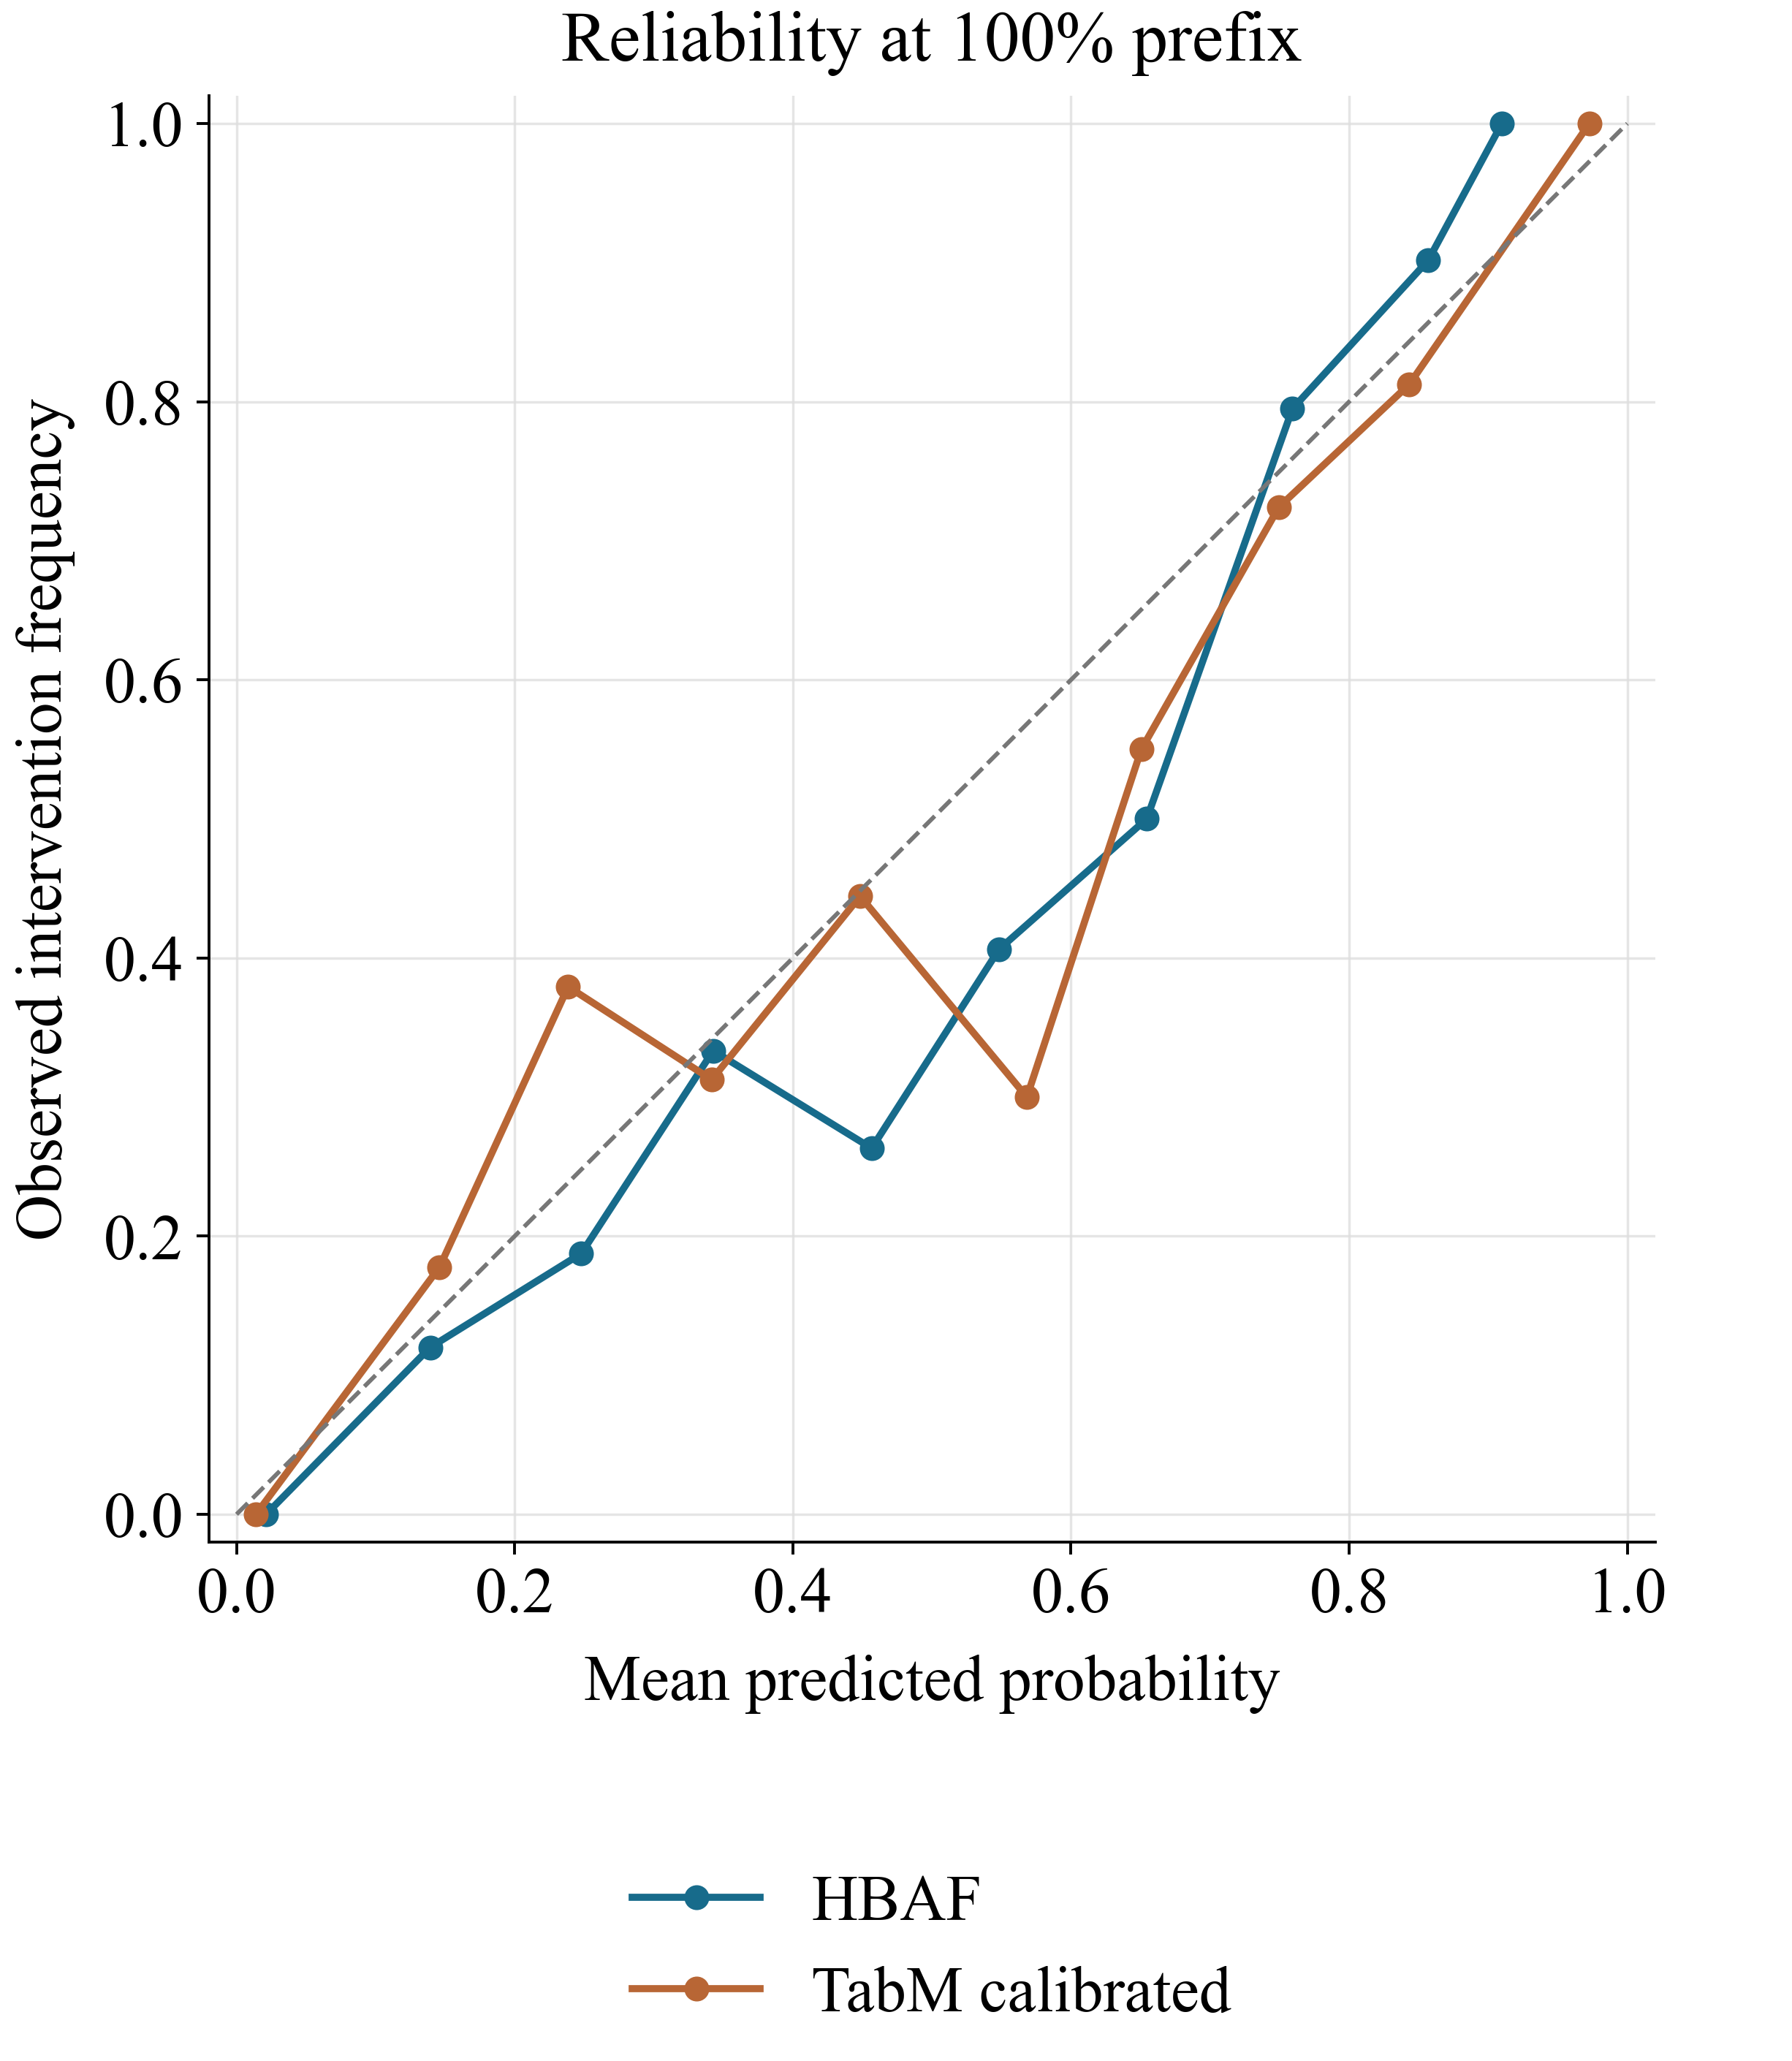

In [22]:
calibration_models = ["HBAF", "TabM calibrated"]
calibration_rows = []
for model_name in calibration_models:
    model_predictions = predictions.loc[predictions["model"].eq(model_name)]
    assert not model_predictions.empty
    path_probability = model_predictions.groupby("cutting_path_id", sort=False).agg(
        probability=("probability", "mean"), target=("target", "first"))
    bins = pd.cut(path_probability["probability"], np.linspace(0, 1, 11), include_lowest=True)
    for _, values in path_probability.groupby(bins, observed=True):
        calibration_rows.append({"Model": model_name, "Mean probability": values.probability.mean(),
                                 "Observed frequency": values.target.mean(), "n": len(values)})
calibration_curve = pd.DataFrame(calibration_rows)
fig, axis = result_axis("Reliability at 100% prefix", "Mean predicted probability", "Observed intervention frequency")
for model_name in calibration_models:
    points = calibration_curve.loc[calibration_curve["Model"].eq(model_name)]
    axis.plot(points["Mean probability"], points["Observed frequency"], "o-",
              label=model_name, color=COLORS[model_name], linewidth=2)
axis.plot([0, 1], [0, 1], color="#777777", linestyle="--", linewidth=1.2)
axis.set(xlim=(-0.02, 1.02), ylim=(-0.02, 1.02))
axis.legend(loc="upper center", bbox_to_anchor=(0.5, -0.19), ncol=1, frameon=False)
save_result_figure(fig, "06_current_hbaf_reliability.png")


The curve uses the five-repeat mean probability per cutting path and is descriptive. Its aggregation differs from the primary mean-of-repeat scores, which remain the basis for statistical inference. Empty bins are omitted rather than displayed as zero observations.

## Accuracy of the Bayesian posterior approximation

Does the conditional single-mode Laplace approximation agree with an adequate independent posterior reference? The fixed-hyperparameter diagnostic examines one development training boundary and does not modify any held-out predictions.


In [23]:
posterior_identifiers = ["Boundary", "n"]
proposal_quality = ["Distinct modes", "Proposal draws", "Importance ESS", "Largest normalized weight"]
approximation_difference = ["Mean-risk RMSE", "Maximum mean-risk difference", "Posterior-SD RMSE"]
monte_carlo_precision = ["Median Monte Carlo SE", "Maximum Monte Carlo SE"]
assert posterior_diagnostic[posterior_identifiers].notna().all().all()
assert posterior_diagnostic["Importance ESS"].gt(0).all()
assert posterior_diagnostic["Importance ESS"].le(posterior_diagnostic["Proposal draws"]).all()
show_table(posterior_diagnostic, posterior_identifiers, proposal_quality, emphasize=False)
show_table(posterior_diagnostic, posterior_identifiers, approximation_difference, emphasize=False)
show_table(posterior_diagnostic, posterior_identifiers, monte_carlo_precision, emphasize=False)


Boundary,n,Distinct modes,Proposal draws,Importance ESS,Largest normalized weight
R1/F1 training; fixed hyperparameters,371,2,4096,12.8599,0.1894


Boundary,n,Mean-risk RMSE,Maximum mean-risk difference,Posterior-SD RMSE
R1/F1 training; fixed hyperparameters,371,0.0620,0.1392,0.0302


Boundary,n,Median Monte Carlo SE,Maximum Monte Carlo SE
R1/F1 training; fixed hyperparameters,371,0.0312,0.0628


The diagnostic used 4,096 proposal draws, identified two distinct modes and obtained an effective sample size of approximately 12.86. The importance reference is therefore too imprecise to validate or reject the Laplace approximation conclusively; the observed discrepancies are not proof that Laplace is false. Conditional posterior uncertainty remains unvalidated, and no calibrated credible-interval claim is made. This limitation does not invalidate already computed held-out predictive metrics.


## Uncertainty and selective prediction

Does uncertainty identify unreliable decisions at the same retained coverage? Policies are compared at identical coverage levels without selecting a favourable operating point from outer outcomes.

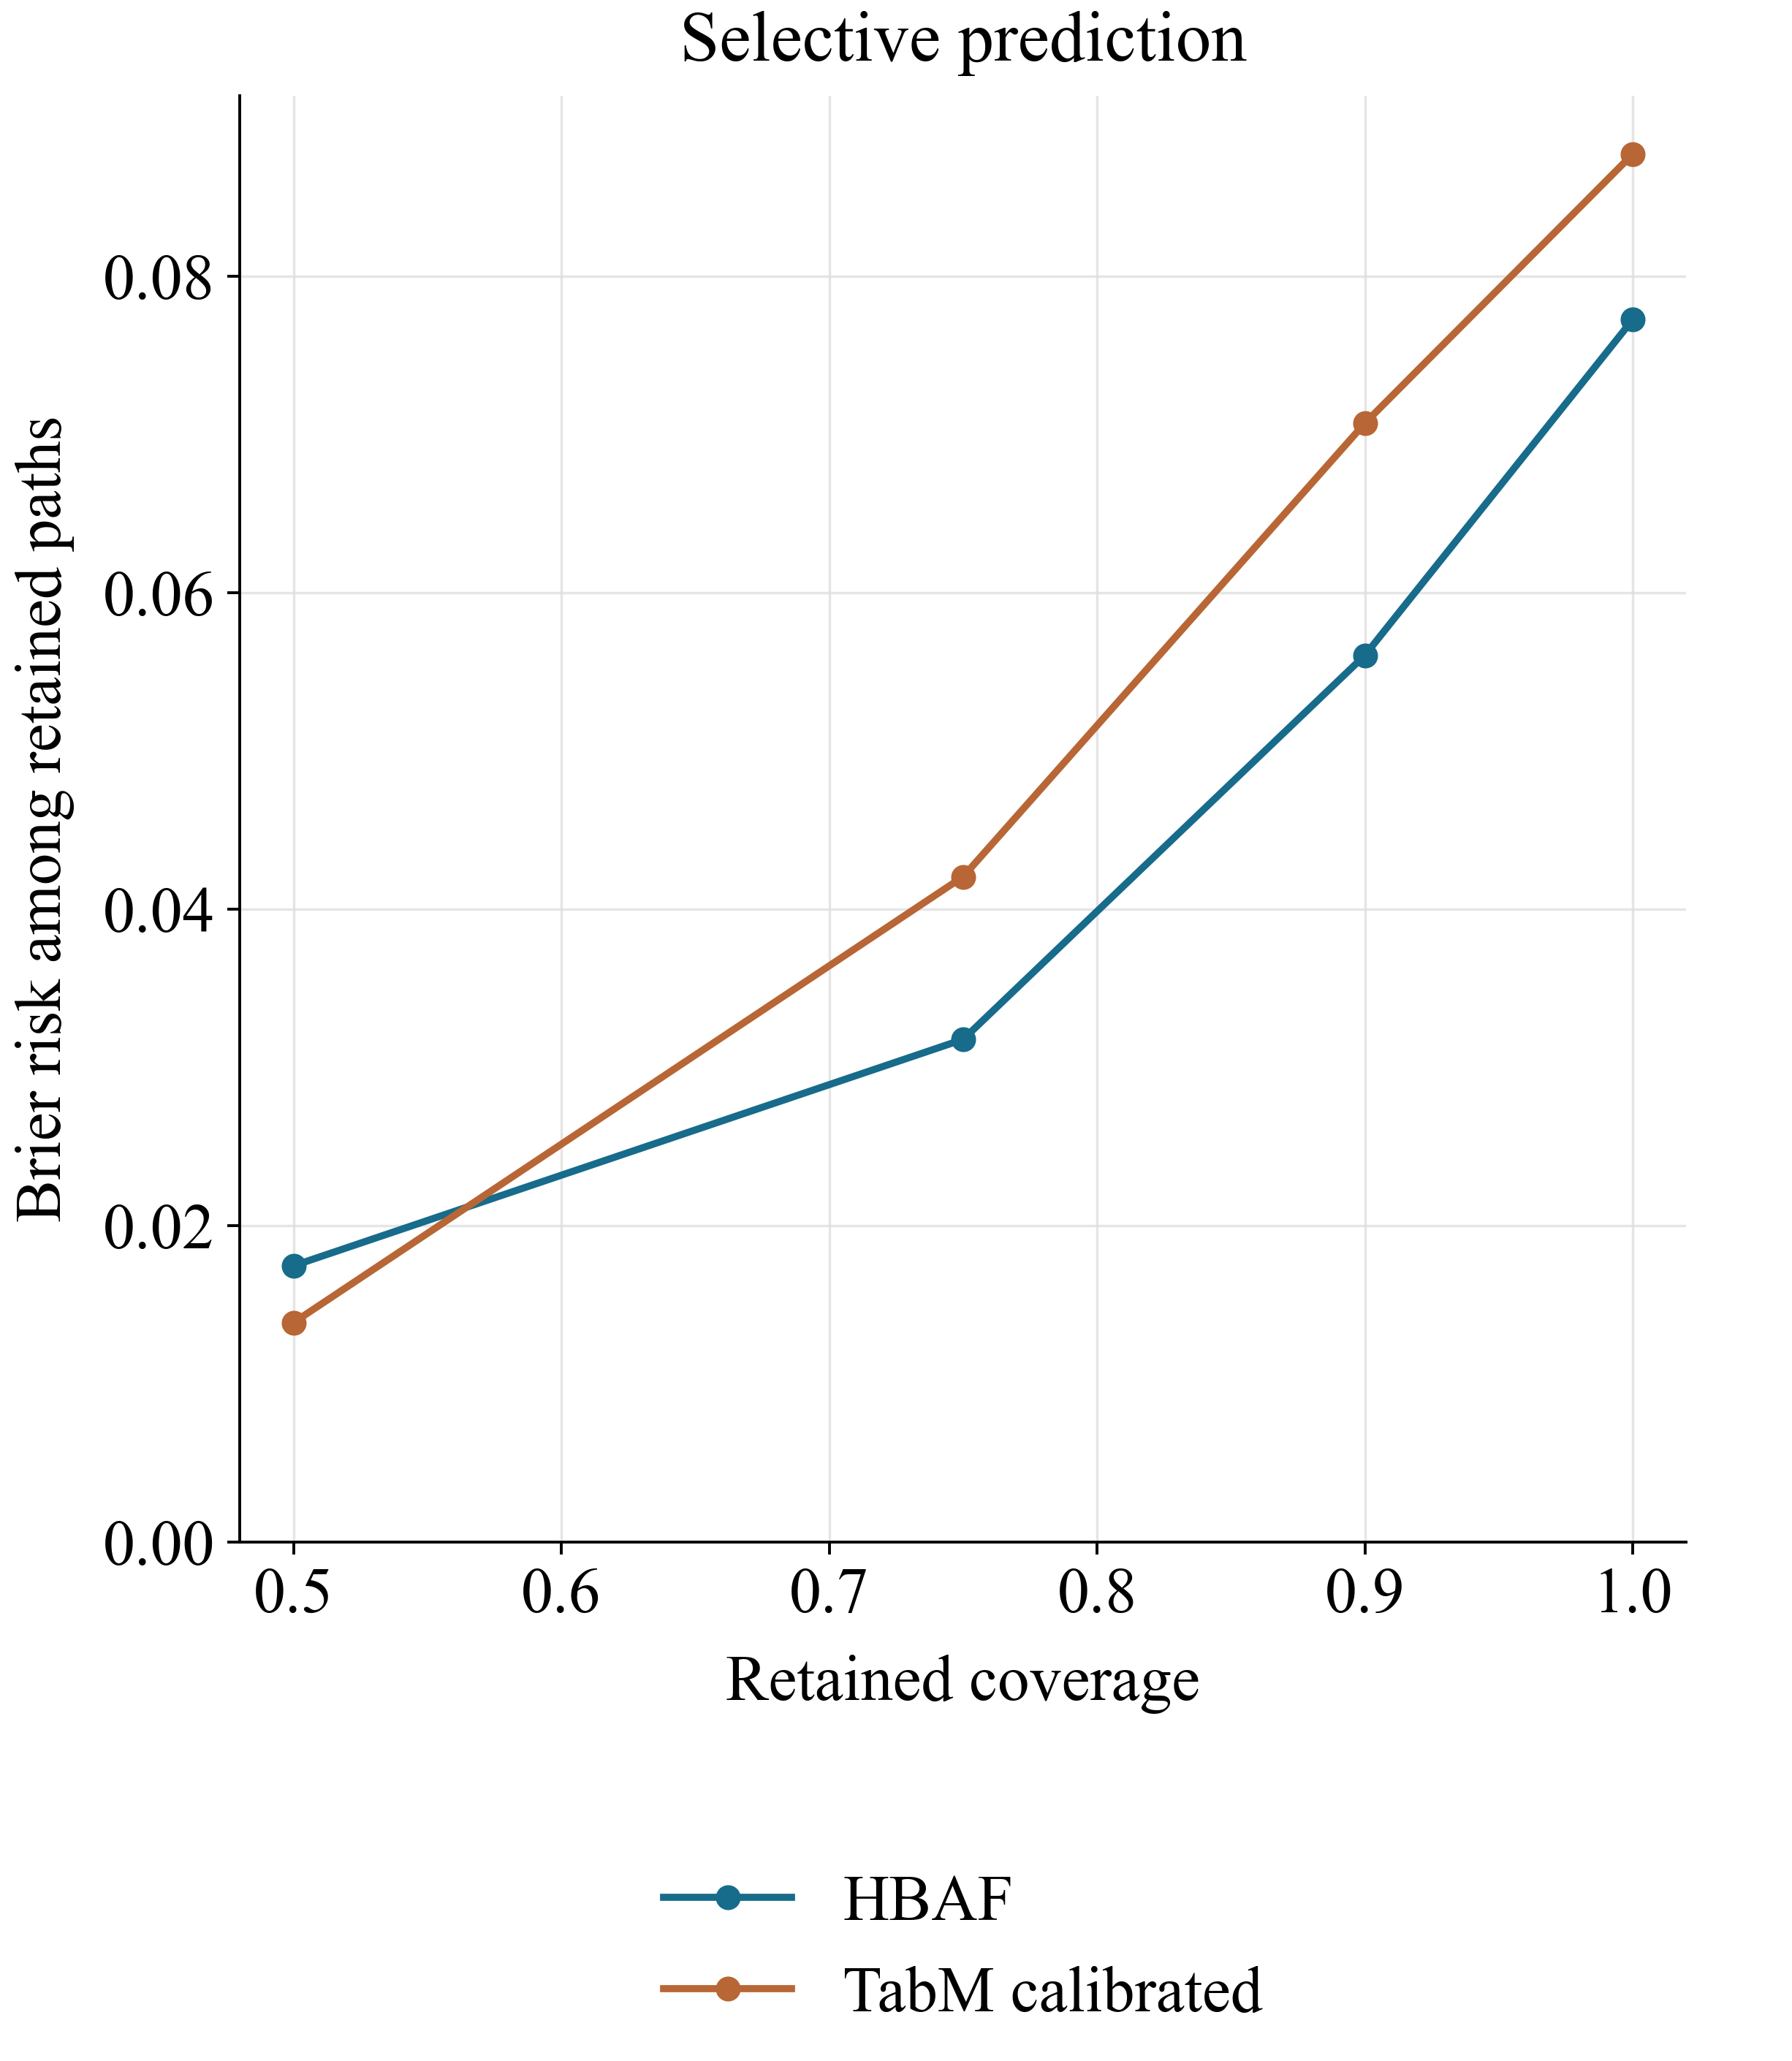

In [24]:
coverage_models = ["HBAF", "TabM calibrated"]
coverage_policies = {"HBAF": "Bayesian uncertainty", "TabM calibrated": "Parent entropy"}
fig, axis = result_axis("Selective prediction", "Retained coverage", "Brier risk among retained paths")
for model_name in coverage_models:
    selected = risk_coverage.loc[risk_coverage["Model"].eq(model_name)
                                & risk_coverage["Policy"].eq(coverage_policies[model_name])].copy()
    selected = selected.sort_values("Coverage")
    assert not selected.empty and not selected["Coverage"].duplicated().any()
    axis.plot(selected["Coverage"], selected["Brier risk"], "o-", linewidth=2,
              label=model_name, color=COLORS[model_name])
axis.set_xlim(risk_coverage["Coverage"].min() - 0.02, 1.02)
axis.set_ylim(bottom=0)
axis.legend(loc="upper center", bbox_to_anchor=(0.5, -0.19), ncol=1, frameon=False)
save_result_figure(fig, "06_current_hbaf_risk_coverage.png")


Lower risk at the same coverage is favourable. The curves do not establish statistically reliable selective benefit by themselves; that conclusion requires the matched inferential evidence from Notebook 05. The uncertainty score is conditional on an unvalidated single-mode Laplace approximation. Its empirical ranking may be assessed, but the displayed probabilities do not establish calibrated Bayesian credible-interval coverage.

## Decision-support consequences

Across operationally interpretable intervention thresholds, how does net benefit compare with the matched parent and simple always/never intervention policies? These thresholds express decision costs and do not retrain or recalibrate a model.

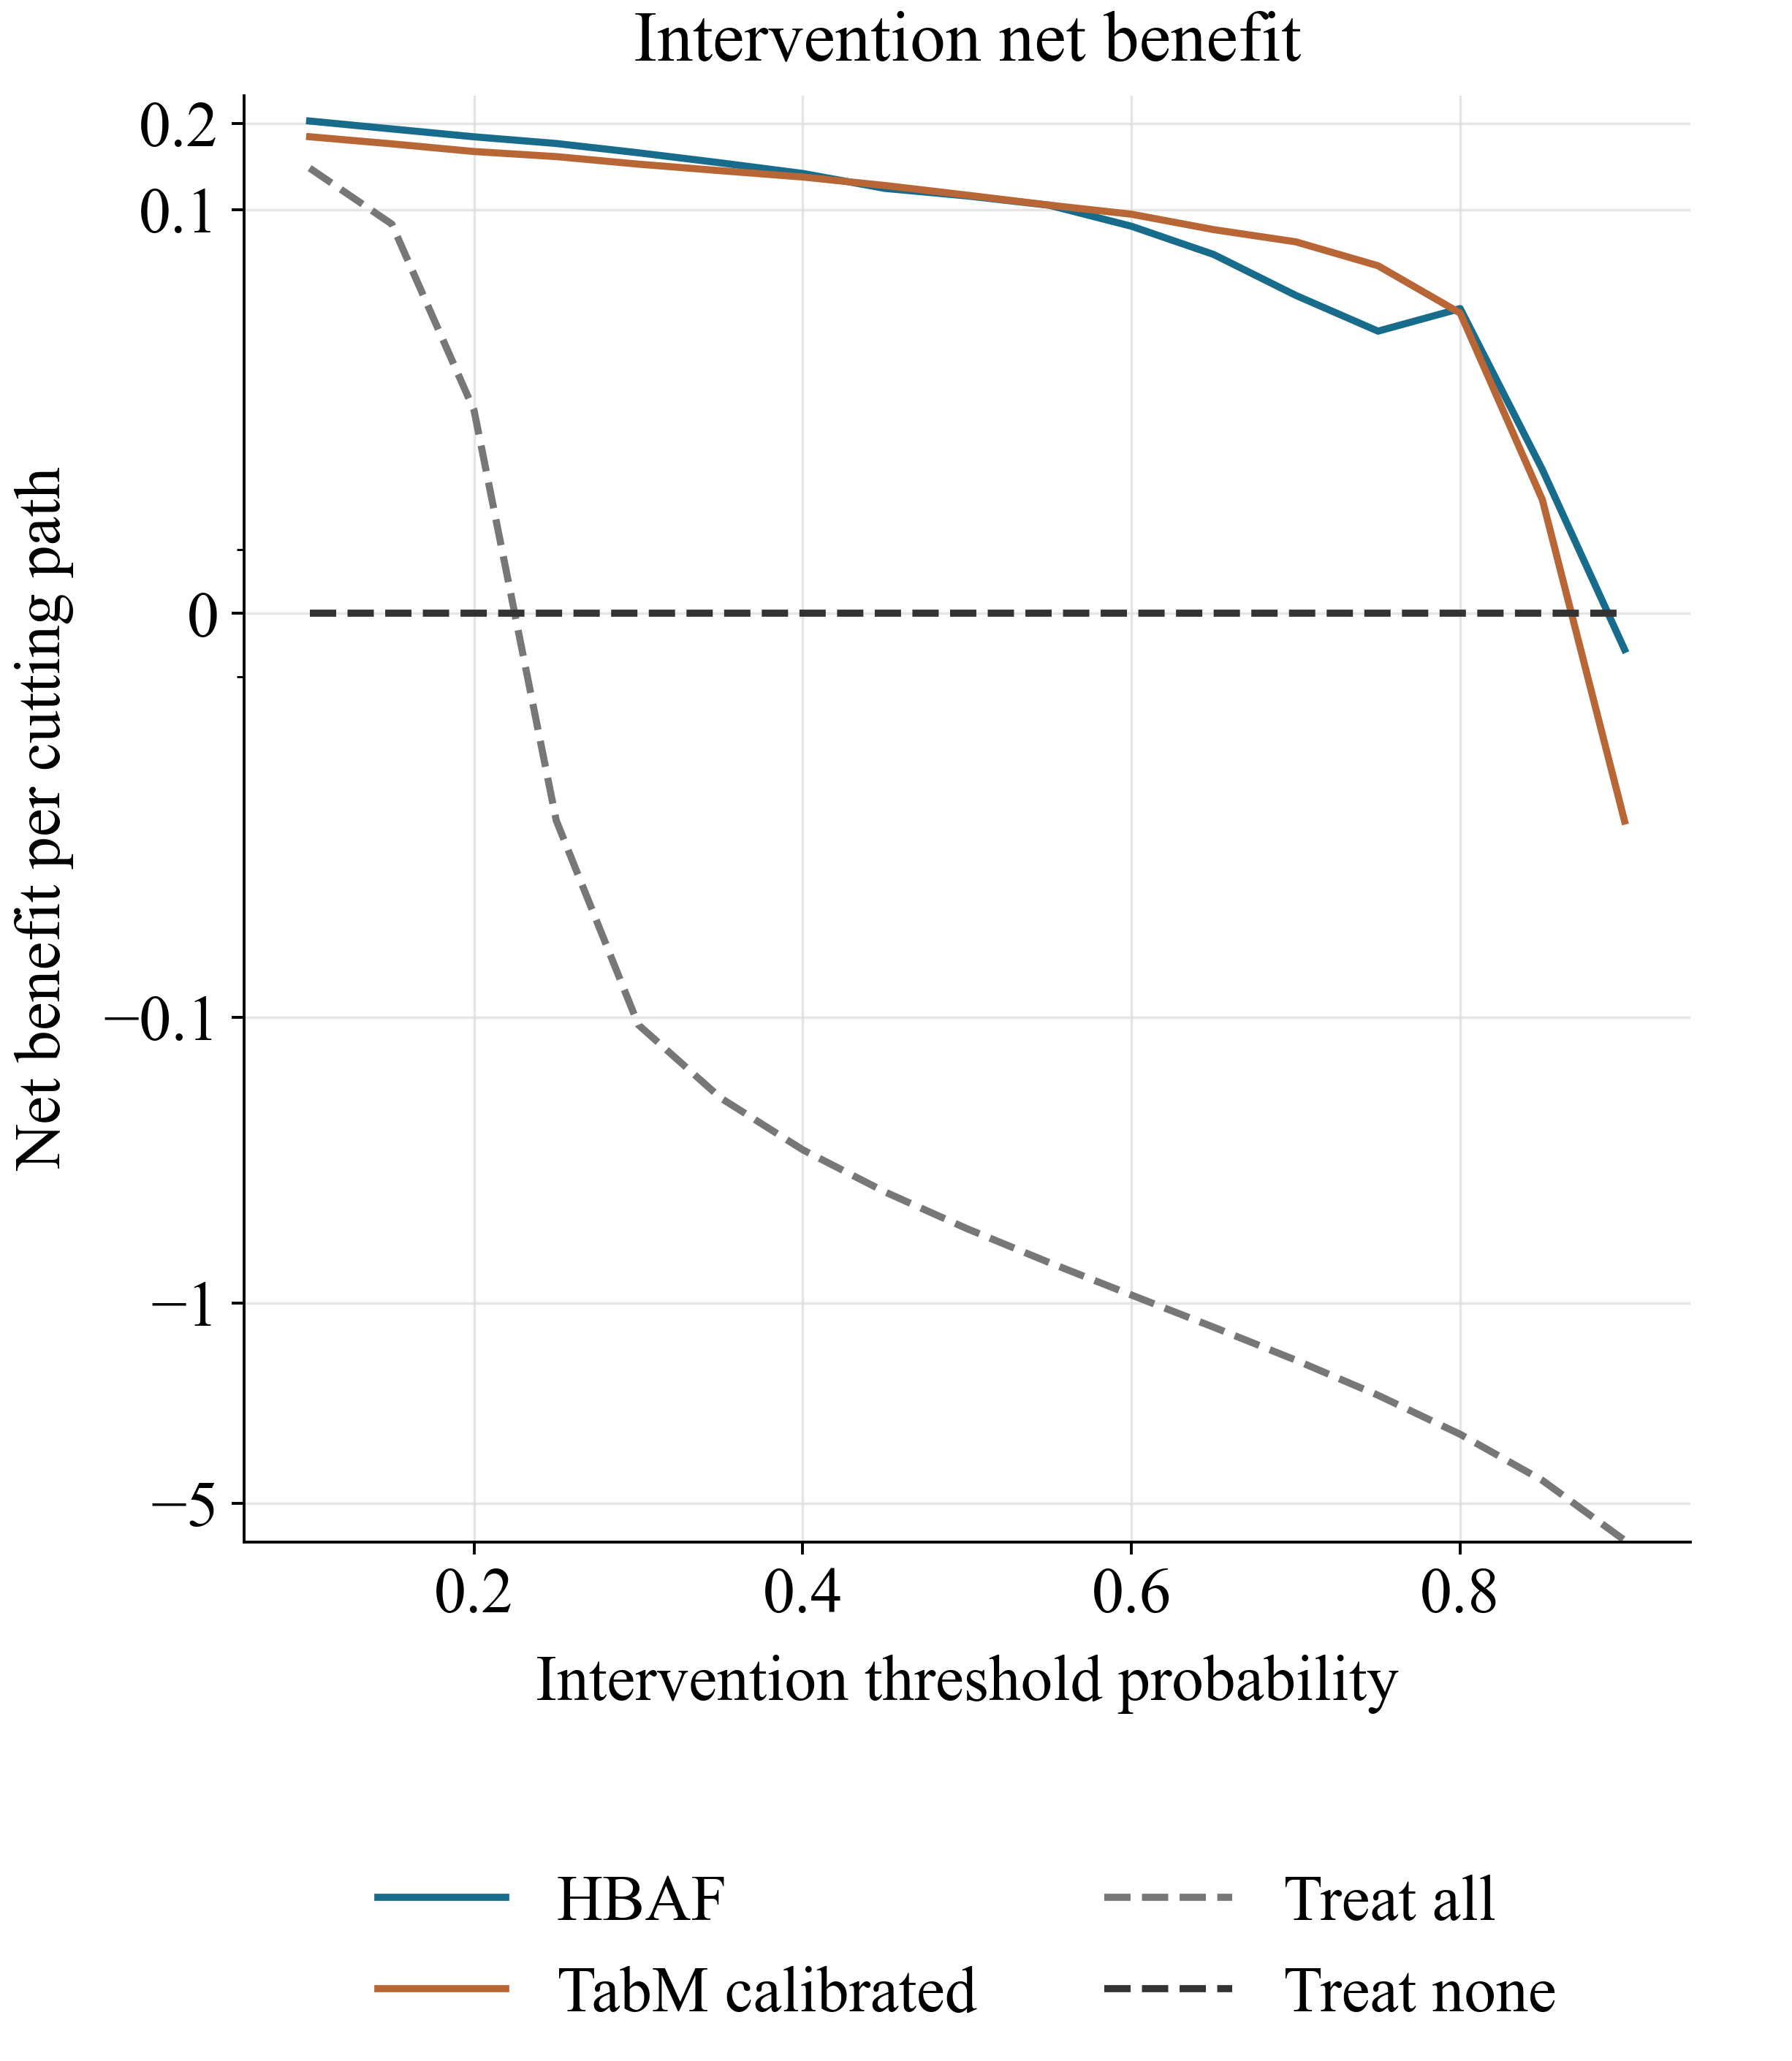

In [25]:
decision_models = ["HBAF", "TabM calibrated", "Treat all", "Treat none"]
fig, axis = result_axis("Intervention net benefit", "Intervention threshold probability", "Net benefit per cutting path")
for model_name in decision_models:
    values = decision_curve.loc[decision_curve["Model"].eq(model_name)].sort_values("Threshold")
    if values.empty:
        continue
    assert not values["Threshold"].duplicated().any()
    color = COLORS.get(model_name, "#777777" if model_name == "Treat all" else "#333333")
    axis.plot(values["Threshold"], values["Net benefit"], label=model_name,
              color=color, linewidth=2, linestyle="-" if model_name in COLORS else "--")
from matplotlib.ticker import FuncFormatter
minimum_benefit = float(decision_curve.loc[decision_curve["Model"].isin(decision_models), "Net benefit"].min())
axis.set_yscale("symlog", linthresh=0.05)
axis.set_ylim(minimum_benefit - 0.1, 0.25)
axis.set_yticks([-5, -1, -0.1, 0, 0.1, 0.2])
axis.yaxis.set_major_formatter(FuncFormatter(lambda value, position: f"{value:g}".replace("-", "−")))
axis.legend(loc="upper center", bbox_to_anchor=(0.5, -0.19), ncol=2, frameon=False)
save_result_figure(fig, "06_current_hbaf_decision_curve.png")


Net benefit is conditional on the interpretation of intervention cost. The symmetric-log y-axis is linear within ±0.05 and logarithmic beyond that region, preserving every negative treat-all point while resolving smaller model differences. These curves are development decision-support evidence, not a measured production benefit or a recommendation to deploy automatically.


## Internal and cross-machine evidence boundary

No current-HBAF Internal or cross-machine result is computed here. Both previously inspected domains can support a later, explicitly frozen descriptive generalization assessment. Their historical HBARF results cannot be relabelled as results of the current HBAF. A new machine or experiment cohort not used in refinement is needed for genuinely independent confirmation.

## Summary and limitations

The displayed development results do not establish a consistent advantage of HBAF over its matched controls. Negative ablations and uncertain effects remain part of the comparison. The single-mode Laplace approximation is unvalidated, and the available timing measurements cover different computational scopes. An independent experiment or machine cohort is required to assess generalization beyond repeated development refinement.
